<a href="https://colab.research.google.com/github/neomatekane/FUTURE_DS_01/blob/main/TASK02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")#load dataset
print(df.shape)
print(df.head(3))
print(df.columns)
print(df.info())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   
2          No          No              No  Month-to-month              Yes   

      PaymentMethod MonthlyCharges  TotalCharges C

In [ ]:
print(df['Churn'].value_counts()) # number of customers who left and the number of customers who stayed

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
churn_rate=df['Churn'].value_counts()[1]/df['Churn'].value_counts()[0]*100# percentage of customers who left
print(f'Overall churn rate:{churn_rate:.2f}%')

Overall churn rate:36.12%


In [ ]:
contract_churn=df.groupby('Contract')['Churn'].value_counts(normalize=True) #customers who left or stayed over time
tenure_churn=df.groupby('tenure')['Churn'].value_counts(normalize=True)
totalcharges_churn=df.groupby('TotalCharges')['Churn'].value_counts(normalize=True)
print(contract_churn)
print(tenure_churn)
print(totalcharges_churn)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64
tenure  Churn
0       No       1.000000
1       Yes      0.619902
        No       0.380098
2       Yes      0.516807
        No       0.483193
                   ...   
70      Yes      0.092437
71      No       0.964706
        Yes      0.035294
72      No       0.983425
        Yes      0.016575
Name: proportion, Length: 145, dtype: float64
TotalCharges  Churn
              No       1.0
100.2         No       1.0
100.25        Yes      1.0
100.35        No       1.0
100.4         Yes      1.0
                      ... 
997.75        No       1.0
998.1         No       1.0
999.45        Yes      1.0
999.8         No       1.0
999.9         No       1.0
Name: proportion, Length: 6698, dtype: float64


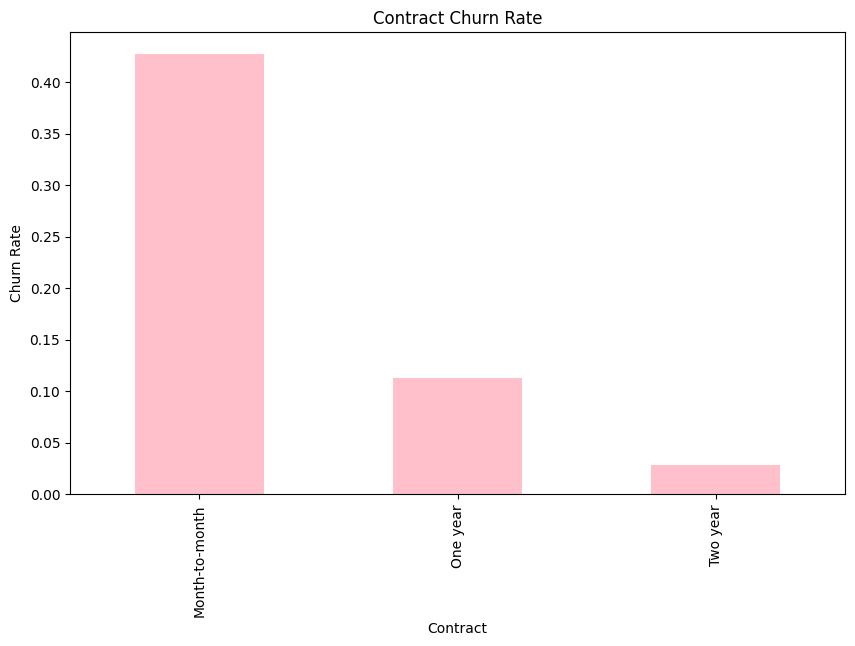

In [ ]:
contract_churn.xs('Yes', level='Churn').plot(kind='bar',figsize=(10,6),color='pink')# plot for churn rate for each contract type
plt.title('Contract Churn Rate')
plt.xlabel('Contract')
plt.ylabel('Churn Rate')
plt.show()

In [ ]:
gender_senior_citizen=df.groupby(['gender','SeniorCitizen'])['Churn'].value_counts(normalize=True)#customers who churn and are senior citizens
print(gender_senior_citizen)



gender  SeniorCitizen  Churn
Female  0              No       0.760616
                       Yes      0.239384
        1              No       0.577465
                       Yes      0.422535
Male    0              No       0.767192
                       Yes      0.232808
        1              No       0.588850
                       Yes      0.411150
Name: proportion, dtype: float64


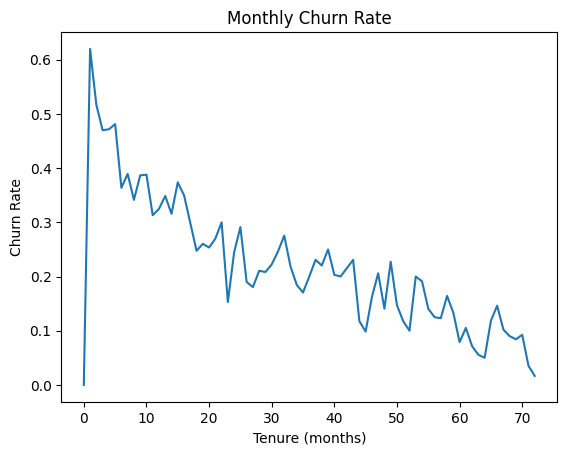

In [ ]:
df['tenure_month']=df['tenure']# when are customers are most likely to leave
monthly_churn=df.groupby('tenure_month')['Churn'].value_counts(normalize=True).unstack().fillna(0)['Yes']
monthly_churn.plot()
plt.title('Monthly Churn Rate')
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate')
plt.show()




In [ ]:
for col in df.select_dtypes(include='object').columns:
    if col not in ['customerID', 'Churn']:
        print("\n", col)
        print(df.groupby(col)['Churn_numeric'].mean())


 gender
gender
Female    0.269209
Male      0.261603
Name: Churn_numeric, dtype: float64

 Partner
Partner
No     0.329580
Yes    0.196649
Name: Churn_numeric, dtype: float64

 Dependents
Dependents
No     0.312791
Yes    0.154502
Name: Churn_numeric, dtype: float64

 PhoneService
PhoneService
No     0.249267
Yes    0.267096
Name: Churn_numeric, dtype: float64

 MultipleLines
MultipleLines
No                  0.250442
No phone service    0.249267
Yes                 0.286099
Name: Churn_numeric, dtype: float64

 InternetService
InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn_numeric, dtype: float64

 OnlineSecurity
OnlineSecurity
No                     0.417667
No internet service    0.074050
Yes                    0.146112
Name: Churn_numeric, dtype: float64

 OnlineBackup
OnlineBackup
No                     0.399288
No internet service    0.074050
Yes                    0.215315
Name: Churn_numeric, dtype: float64

 DeviceProtectio

In [ ]:
from sklearn.ensemble import RandomForestClassifier #top columns that drive and contribute to churn
import pandas as pd

X = df.drop('Churn', axis=1)
X = pd.get_dummies(X)
y = df['Churn']

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
Churn_numeric,0.359901
tenure_month,0.039589
tenure,0.038609
MonthlyCharges,0.029419
Contract_Month-to-month,0.022006
TechSupport_No,0.014863
InternetService_Fiber optic,0.010662
PaymentMethod_Electronic check,0.010392
OnlineSecurity_No,0.010281
Contract_Two year,0.010046


In [ ]:
retention_index=(1-churn_rate/100)*100 #how many customers stayed
print(f'Retention index:{retention_index:.2f}%')

Retention index:63.88%


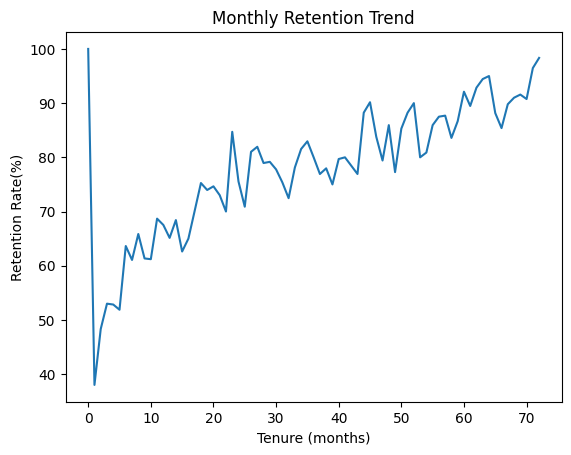

In [ ]:
monthly_total=df.groupby('tenure_month').size() #percentage of how many customers stay active each month
monthly_retained=df[df['Churn']=='No'].groupby('tenure_month').size()
retention_trend=(monthly_retained/monthly_total*100).fillna(0)
retention_trend.plot()
plt.title('Monthly Retention Trend')
plt.xlabel('Tenure (months)')
plt.ylabel('Retention Rate(%)')
plt.show()

In [ ]:
risk_segments=pd.crosstab([df['Contract'],df['PaymentMethod']],df['Churn'],normalize='index').reset_index()#churn by contract type and payment method combination
top_risks=risk_segments.sort_values('Yes',ascending=False).head(5)
print(top_risks[['Contract','PaymentMethod', 'Yes']])

Churn        Contract              PaymentMethod       Yes
2      Month-to-month           Electronic check  0.537297
0      Month-to-month  Bank transfer (automatic)  0.341256
1      Month-to-month    Credit card (automatic)  0.327808
3      Month-to-month               Mailed check  0.315789
6            One year           Electronic check  0.184438
